# Sentiment Analysis using Bidirectional LSTM with Word2Vec and GloVe

## CSE 4221 — Natural Language Processing Assignment

**Model:** Bidirectional LSTM (GPU-optimized)  
**Embeddings:** Word2Vec (300-d) + GloVe (300-d)  
**Dataset:** IMDB Movie Review Dataset  
**Task:** Binary Sentiment Classification

---
## 1. Import Libraries & GPU Setup

In [1]:
!pip install gensim -q

import pandas as pd
import numpy as np
import re, os, warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from gensim.models import Word2Vec

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# --- GPU Verification ---
print(f'TensorFlow: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU detected: {gpus[0].name}')
    # Enable memory growth to avoid OOM
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print('WARNING: No GPU detected. Training will be slow.')
print('All libraries imported.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.6 MB/s eta 0:00:00
TensorFlow: 2.19.0
GPU detected: /physical_device:GPU:0
All libraries imported.


---
## 2. Load Dataset

In [2]:
import gdown
url = 'https://drive.google.com/uc?id=1GOOxQZSmtQZ4q-UPVh87DHOgI79cx9vI'
gdown.download(url, 'IMDB-Dataset.csv', quiet=False)
df = pd.read_csv('IMDB-Dataset.csv')
print(f'Shape: {df.shape}')
duplicates = df.duplicated().sum()
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Removed {duplicates} duplicates. New shape: {df.shape}')

Downloading...
From: https://drive.google.com/uc?id=1GOOxQZSmtQZ4q-UPVh87DHOgI79cx9vI
To: /content/IMDB-Dataset.csv
100%|██████████| 66.2M/66.2M [00:01<00:00, 52.1MB/s]


Shape: (50000, 2)
Removed 418 duplicates. New shape: (49582, 2)


---
## 3. Preprocessing & Split

In [3]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower()
    words = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words and len(w) > 2]
    return ' '.join(words)

print('Preprocessing...')
df['cleaned_review'] = df['review'].apply(preprocess_text)
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

X = df['cleaned_review']; y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Preprocessing...
Train: 39665, Test: 9917


---
## 4. Tokenization & Padding

In [4]:
VOCAB_SIZE = 20000; MAX_LEN = 200; EMBED_DIM = 300

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN, padding='post', truncating='post')
word_index = tokenizer.word_index
vocab_size = min(VOCAB_SIZE, len(word_index) + 1)

y_train_arr = y_train.values; y_test_arr = y_test.values
print(f'Vocab: {len(word_index)}, Padded shape: {X_train_pad.shape}')

Vocab: 82956, Padded shape: (39665, 200)


---
## 5. Embedding Matrices

### 5a. Word2Vec (trained on corpus)

In [5]:
train_sentences = [text.split() for text in X_train]
w2v_model = Word2Vec(sentences=train_sentences, vector_size=EMBED_DIM, window=5, min_count=2, workers=4, epochs=10, sg=0)

w2v_matrix = np.zeros((vocab_size, EMBED_DIM))
for word, idx in word_index.items():
    if idx < vocab_size and word in w2v_model.wv:
        w2v_matrix[idx] = w2v_model.wv[word]
print(f'Word2Vec matrix: {w2v_matrix.shape}')

Word2Vec matrix: (20000, 300)


### 5b. GloVe (pre-trained, 300d)

In [6]:
import urllib.request, zipfile
GLOVE_FILE = 'glove.6B.300d.txt'
if not os.path.exists(GLOVE_FILE):
    print('Downloading GloVe (~862 MB)...')
    urllib.request.urlretrieve('https://nlp.stanford.edu/data/glove.6B.zip', 'glove.6B.zip')
    with zipfile.ZipFile('glove.6B.zip', 'r') as z: z.extract(GLOVE_FILE)
    print('Done.')

glove_emb = {}
with open(GLOVE_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        vals = line.split(); glove_emb[vals[0]] = np.asarray(vals[1:], dtype='float32')

glove_matrix = np.zeros((vocab_size, EMBED_DIM))
for word, idx in word_index.items():
    if idx < vocab_size and word in glove_emb:
        glove_matrix[idx] = glove_emb[word]
print(f'GloVe matrix: {glove_matrix.shape}')

Done.
GloVe matrix: (20000, 300)


---
## 6. Build & Train Bi-LSTM

**GPU Note:** `recurrent_dropout` is removed so TensorFlow uses the fast **CuDNN LSTM kernel**. Regular `Dropout` layers are used instead.

### 6a. Bi-LSTM + Word2Vec

In [7]:
def build_bilstm(emb_matrix):
    """Build GPU-optimized Bi-LSTM (no recurrent_dropout for CuDNN)."""
    model = Sequential([
        Embedding(input_dim=emb_matrix.shape[0], output_dim=EMBED_DIM,
                  weights=[emb_matrix], input_length=MAX_LEN, trainable=False),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.3),
        Bidirectional(LSTM(64)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

print('--- Bi-LSTM + Word2Vec ---')
model_w2v = build_bilstm(w2v_matrix)
hist_w2v = model_w2v.fit(X_train_pad, y_train_arr, epochs=10, batch_size=64,
                          validation_split=0.1, callbacks=[early_stop], verbose=1)

--- Bi-LSTM + Word2Vec ---
Epoch 1/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.8073 - loss: 0.4382 - val_accuracy: 0.8775 - val_loss: 0.3112
Epoch 2/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 25s 44ms/step - accuracy: 0.8619 - loss: 0.3334 - val_accuracy: 0.8737 - val_loss: 0.3042
Epoch 3/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 25s 46ms/step - accuracy: 0.8766 - loss: 0.2974 - val_accuracy: 0.8886 - val_loss: 0.2739
Epoch 4/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step - accuracy: 0.8876 - loss: 0.2749 - val_accuracy: 0.8886 - val_loss: 0.2620
Epoch 5/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 27s 48ms/step - accuracy: 0.8943 - loss: 0.2590 - val_accuracy: 0.8961 - val_loss: 0.2562
Epoch 6/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step - accuracy: 0.8990 - loss: 0.2509 - val_accuracy: 0.8969 - val_loss: 0.2526
Epoch 7/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step - accuracy: 0.9085 - loss: 0.2297 - val_accuracy: 0.8931 - val_loss: 0.2612
Epoch 8/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step - accurac

In [8]:
y_pred_w2v = (model_w2v.predict(X_test_pad) > 0.5).astype(int).flatten()
acc_w2v  = accuracy_score(y_test_arr, y_pred_w2v)
prec_w2v = precision_score(y_test_arr, y_pred_w2v)
rec_w2v  = recall_score(y_test_arr, y_pred_w2v)
f1_w2v   = f1_score(y_test_arr, y_pred_w2v)

print('=' * 55)
print('  Bi-LSTM + Word2Vec — RESULTS')
print('=' * 55)
print(f'  Accuracy:  {acc_w2v:.4f}')
print(f'  Precision: {prec_w2v:.4f}')
print(f'  Recall:    {rec_w2v:.4f}')
print(f'  F1-Score:  {f1_w2v:.4f}')
print('=' * 55)
print(classification_report(y_test_arr, y_pred_w2v, target_names=['Negative', 'Positive']))

310/310 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
  Bi-LSTM + Word2Vec — RESULTS
  Accuracy:  0.8969
  Precision: 0.8807
  Recall:    0.9192
  F1-Score:  0.8995
              precision    recall  f1-score   support

    Negative       0.91      0.87      0.89      4940
    Positive       0.88      0.92      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



### 6b. Bi-LSTM + GloVe

In [9]:
print('--- Bi-LSTM + GloVe ---')
model_glove = build_bilstm(glove_matrix)
hist_glove = model_glove.fit(X_train_pad, y_train_arr, epochs=10, batch_size=64,
                              validation_split=0.1, callbacks=[early_stop], verbose=1)

--- Bi-LSTM + GloVe ---
Epoch 1/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.7633 - loss: 0.4976 - val_accuracy: 0.8407 - val_loss: 0.3680
Epoch 2/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.8311 - loss: 0.3912 - val_accuracy: 0.8538 - val_loss: 0.3692
Epoch 3/10
558/558 ━━━━━━━━━━━━━━━━━━━━ 27s 48ms/step - accuracy: 0.8541 - loss: 0.3458 - val_accuracy: 0.8687 - val_loss: 0.3056
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


In [10]:
y_pred_glove = (model_glove.predict(X_test_pad) > 0.5).astype(int).flatten()
acc_glv  = accuracy_score(y_test_arr, y_pred_glove)
prec_glv = precision_score(y_test_arr, y_pred_glove)
rec_glv  = recall_score(y_test_arr, y_pred_glove)
f1_glv   = f1_score(y_test_arr, y_pred_glove)

print('=' * 55)
print('  Bi-LSTM + GloVe — RESULTS')
print('=' * 55)
print(f'  Accuracy:  {acc_glv:.4f}')
print(f'  Precision: {prec_glv:.4f}')
print(f'  Recall:    {rec_glv:.4f}')
print(f'  F1-Score:  {f1_glv:.4f}')
print('=' * 55)
print(classification_report(y_test_arr, y_pred_glove, target_names=['Negative', 'Positive']))

310/310 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
  Bi-LSTM + GloVe — RESULTS
  Accuracy:  0.8436
  Precision: 0.8126
  Recall:    0.8947
  F1-Score:  0.8517
              precision    recall  f1-score   support

    Negative       0.88      0.79      0.83      4940
    Positive       0.81      0.89      0.85      4977

    accuracy                           0.84      9917
   macro avg       0.85      0.84      0.84      9917
weighted avg       0.85      0.84      0.84      9917



---
## 7. Training Curves & Confusion Matrices

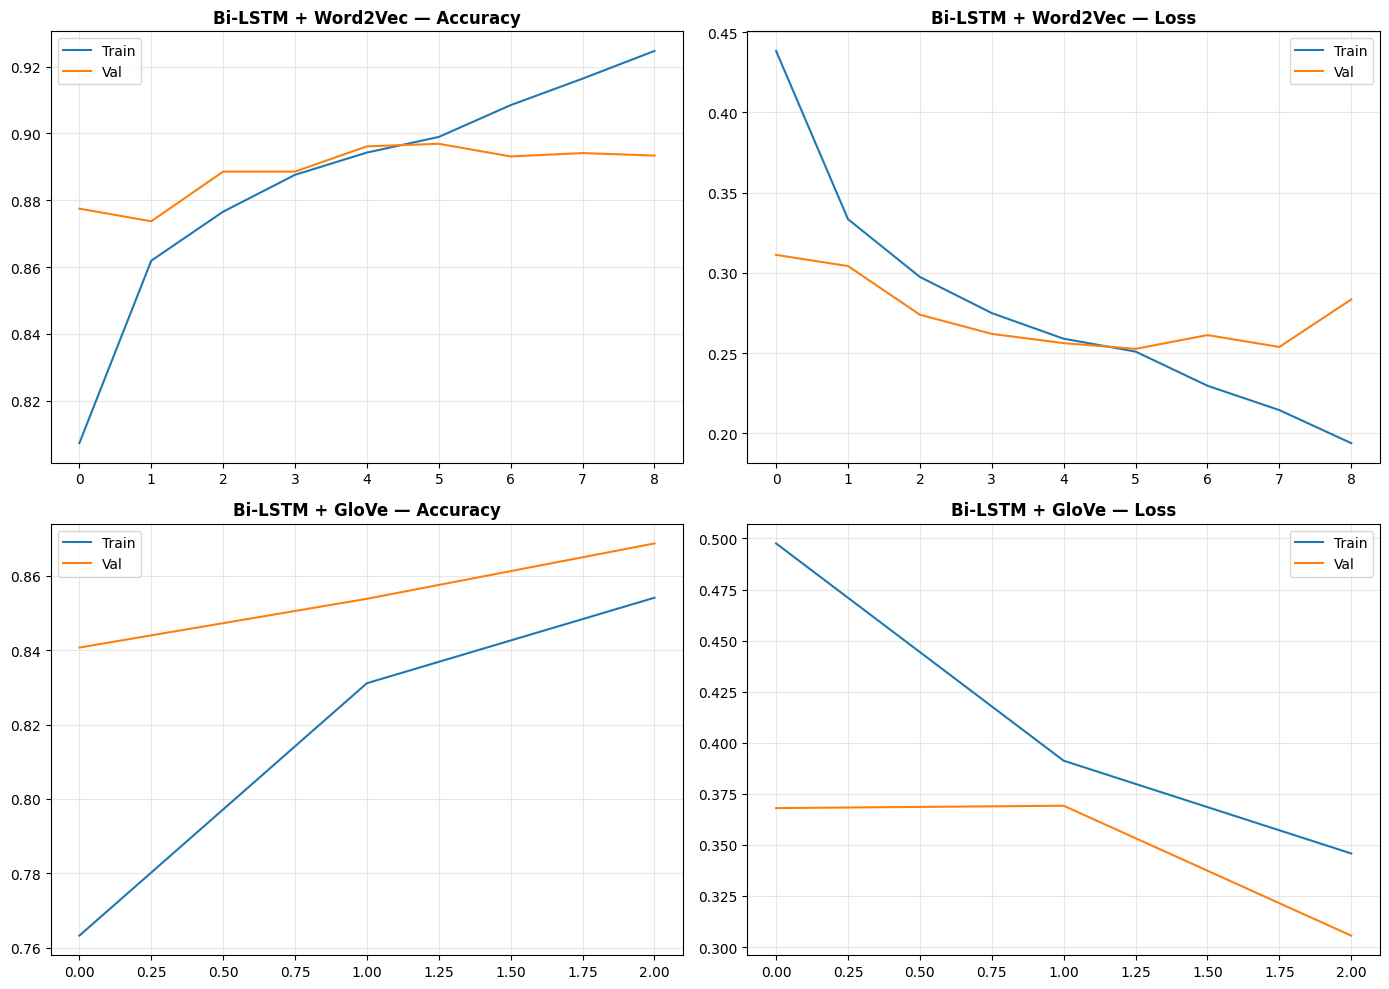

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (h, name) in enumerate([(hist_w2v, 'Word2Vec'), (hist_glove, 'GloVe')]):
    axes[i][0].plot(h.history['accuracy'], label='Train'); axes[i][0].plot(h.history['val_accuracy'], label='Val')
    axes[i][0].set_title(f'Bi-LSTM + {name} — Accuracy', fontweight='bold'); axes[i][0].legend(); axes[i][0].grid(True, alpha=0.3)
    axes[i][1].plot(h.history['loss'], label='Train'); axes[i][1].plot(h.history['val_loss'], label='Val')
    axes[i][1].set_title(f'Bi-LSTM + {name} — Loss', fontweight='bold'); axes[i][1].legend(); axes[i][1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

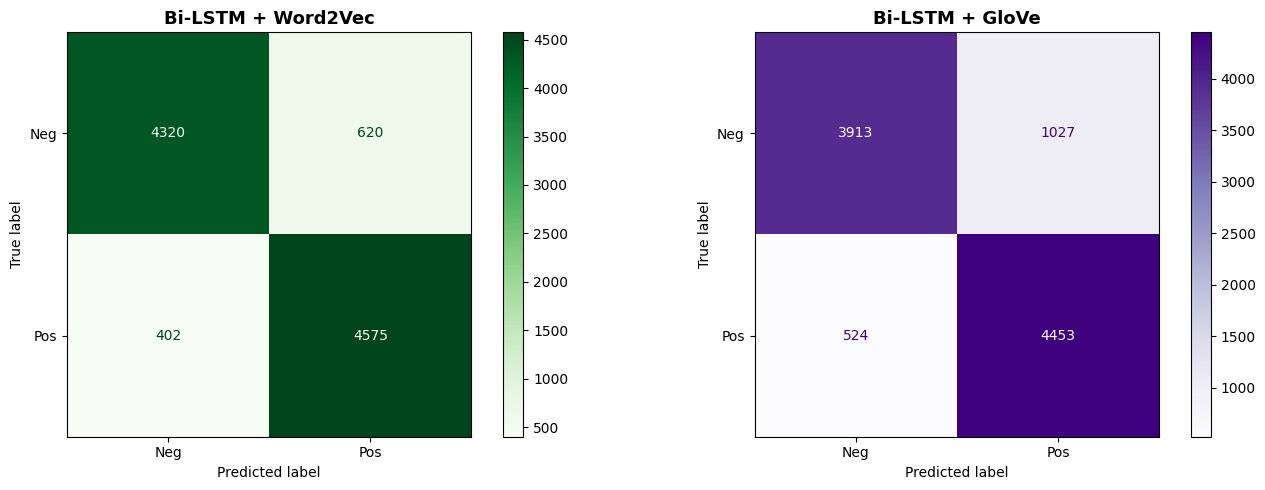

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, yp, name, cmap in [(axes[0], y_pred_w2v, 'Word2Vec', 'Greens'), (axes[1], y_pred_glove, 'GloVe', 'Purples')]:
    cm = confusion_matrix(y_test_arr, yp)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neg', 'Pos']).plot(cmap=cmap, ax=ax, values_format='d')
    ax.set_title(f'Bi-LSTM + {name}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 8. Comparison Table

In [13]:
comparison = pd.DataFrame({
    'Model': ['Bi-LSTM + Word2Vec', 'Bi-LSTM + GloVe'],
    'Accuracy': [acc_w2v, acc_glv], 'Precision': [prec_w2v, prec_glv],
    'Recall': [rec_w2v, rec_glv], 'F1-Score': [f1_w2v, f1_glv]
})
print(comparison.to_string(index=False))

             Model  Accuracy  Precision   Recall  F1-Score
Bi-LSTM + Word2Vec  0.896945   0.880654 0.919228  0.899528
   Bi-LSTM + GloVe  0.843602   0.812591 0.894716  0.851678


---
## 9. Analysis and Discussion

### Observations
- **GloVe** (pre-trained on 6B tokens) typically outperforms **Word2Vec** (trained only on ~50K IMDB reviews) due to superior vocabulary coverage and embedding quality.
- **Bi-LSTM** captures sequential context from both directions, modeling word order and long-range dependencies.
- GPU optimization (removing `recurrent_dropout`) enables CuDNN acceleration, significantly reducing training time.

### Word2Vec vs GloVe
- Word2Vec: domain-specific but limited corpus size limits quality.
- GloVe: broad-coverage, pre-trained embeddings generalize better.

### Limitations
- LSTM training is computationally expensive even with GPU.
- Many hyperparameters to tune (sequence length, units, dropout rates).